# 🐶 Classification of Malignant Melanoma in Canines (CATCH)
### Weeks 1–6 — Segmentation & Classification | Project DAIM2025A_088

**Student:** Muhammad Tayyab Abbas &nbsp;·&nbsp; **Supervisor:** Dr Claire Cashmore &nbsp;·&nbsp; University of Hull

This notebook is the single place that runs and explains the whole project so far:
preprocessing (W1–2), U-Net segmentation (W3–4), the Attention U-Net variant (W5),
and tumour-subtype classification (W6).

## 0. Plan for the classification section — answering the supervisor's questions

> *"Plan the classification part so you are prepared with the segmentation output…
> What is the output of the segmentation? What are you going to classify? How many
> classes? Are there enough of each class? What about balancing — before or after
> the segmentation?"*

**The two-stage pipeline (how segmentation feeds classification):**

```
Whole-slide image
   └─► tile into 256×256 patches (5×/10×/20×)
        └─► [STAGE 1] U-Net SEGMENTATION  ──► per-pixel tumour MASK (tumour vs background)
             └─► keep the patches whose mask says "tumour"  (tumour localisation)
                  └─► [STAGE 2] CNN CLASSIFICATION  ──► tumour SUBTYPE label
```

**Q1 — What is the output of the segmentation?**
A per-pixel **binary mask** for each patch: `1 = tumour`, `0 = background/normal tissue`.
Aggregating the patch masks gives a tumour-region map for the whole slide. This
output is used two ways: (a) to *locate* the tumour, and (b) to *select* the
tumour-containing patches that are then passed to the classifier.

**Q2 — What are we going to classify, and how many classes?**
We classify the **tumour subtype** of each tumour patch. The real CATCH dataset
contains **7 tumour subtypes** — *Melanoma, Mast cell tumour, Squamous cell
carcinoma, Peripheral nerve sheath tumour, Trichoblastoma, Histiocytoma,
Plasmacytoma*. Because the project's focus is **melanoma**, the classifier can run
in two modes: (i) full **7-class** subtype classification, or (ii) **melanoma vs.
non-melanoma** (binary). The demo below uses **3 representative classes**
(melanocytic, mast cell, squamous cell) to validate the pipeline.

**Q3 — Are there enough of each class? (balance)**
CATCH is **imbalanced** — some subtypes have many more slides/patches than others.
We measure the class counts (cell below) and report them so the imbalance is
explicit.

**Q4 — Balancing: before or after the segmentation?**
There are **two different imbalances**, handled at **two different stages**:
- *Segmentation imbalance* (tumour pixels ≈ 9 % vs background) → handled **inside
  segmentation** with a **BCE `pos_weight` + Dice loss**.
- *Class imbalance across subtypes* → handled **after segmentation, at the
  classification stage**, with **class-weighted cross-entropy**, **augmentation**,
  and a **stratified slide-level split**. (A `WeightedRandomSampler` is an
  alternative.)

So: balancing for classification is done **after** segmentation, on the tumour
patches that are fed to the classifier.

## 1. Setup

In [1]:
import sys, os
from pathlib import Path

# find the project root (folder that contains config/config.yaml) and work from there
root = Path.cwd()
while not (root / "config" / "config.yaml").exists() and root != root.parent:
    root = root.parent
os.chdir(root); sys.path.insert(0, str(root))
print("Project root:", root)

import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.utils.config import load_config
cfg = load_config()
LOGS = root / "outputs" / "logs"; FIG = root / "outputs" / "figures"

def show_img(path, title=None, size=(6,6)):
    p = Path(path)
    if not p.exists():
        print("(not found yet — run the pipeline to create:", p.name, ")"); return
    import matplotlib.image as mpimg
    plt.figure(figsize=size); plt.imshow(mpimg.imread(str(p))); plt.axis("off")
    if title: plt.title(title)
    plt.show()

def load_json(name):
    p = LOGS / name
    return json.loads(p.read_text()) if p.exists() else None
print("Setup done.")

Project root: E:\Project\canine-melanoma-catch


Setup done.


## 2. Dataset & scale — *"are you using the full dataset?"*

**Honest status.** No real CATCH slides have been processed yet — every result in
this notebook is computed on **synthetic** slides that exercise the pipeline
end-to-end while the TCIA download is arranged. The synthetic "tumours" and
"subtypes" are drawn shapes/colours, **not** histology, so the numbers validate the
*code*, not the biology.

**The real dataset** (Wilm et al., 2022; TCIA DOI `10.7937/TCIA.2M93-FX66`) is:

| | |
|---|---|
| Slides | **350** pyramidal Aperio `.svs` (level 0 = 0.25 µm/px ≈ 40×) |
| Classes | **7 tumour subtypes**, 50 slides each |
| Subtypes | Melanoma · Mast cell tumour · Squamous cell carcinoma · Peripheral nerve sheath tumour · Trichoblastoma · Histiocytoma · Plasmacytoma |
| Annotations | **12,424 polygons** (MS-COCO JSON + SQLite) → tumour masks |

The pipeline is now **real-data-ready** (native `.svs` tiling, COCO/SQLite mask
parsing, folder-per-subtype labels, slide-level split). Switching to real data is
a flag, not a rewrite — see Section 7. Patch counts below are *extracted patches*
(one slide → many 256×256 tiles at 5×/10×/20×), not slides.

SEGMENTATION patches: {'train': 408, 'val': 57, 'test': 151, 'total': 616}
  magnifications: [5, 10, 20]

CLASSIFICATION patches: {'train': 148, 'val': 80, 'test': 73, 'total': 301}
  classes: {'mast_cell': 0, 'melanocytic': 1, 'squamous_cell': 2}
  class distribution (imbalance): {'melanocytic': 117, 'squamous_cell': 107, 'mast_cell': 77}


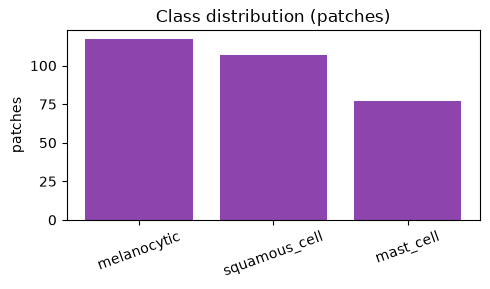

In [2]:
# Segmentation dataset size
seg_sum = json.loads((root/"data/processed/seg_splits/seg_split_summary.json").read_text()) \
    if (root/"data/processed/seg_splits/seg_split_summary.json").exists() else None
if seg_sum:
    print("SEGMENTATION patches:", seg_sum["patches"])
    print("  magnifications:", seg_sum.get("magnifications"))

# Classification dataset size + class balance
cls_sum = json.loads((root/"data/processed/cls_splits/cls_split_summary.json").read_text()) \
    if (root/"data/processed/cls_splits/cls_split_summary.json").exists() else None
if cls_sum:
    print("\nCLASSIFICATION patches:", cls_sum["patches"])
    print("  classes:", cls_sum["classes"])
    dist = cls_sum["class_distribution"]
    print("  class distribution (imbalance):", dist)
    plt.figure(figsize=(5,3)); plt.bar(dist.keys(), dist.values(), color="#8E44AD")
    plt.title("Class distribution (patches)"); plt.ylabel("patches"); plt.xticks(rotation=20)
    plt.tight_layout(); plt.show()

## 3. Weeks 1–2 — Preprocessing (live demo)

Quality check → **Macenko stain normalisation** → **tissue detection** →
**multi-magnification patch extraction** → stratified split. Below we run the key
steps live on one synthetic slide.

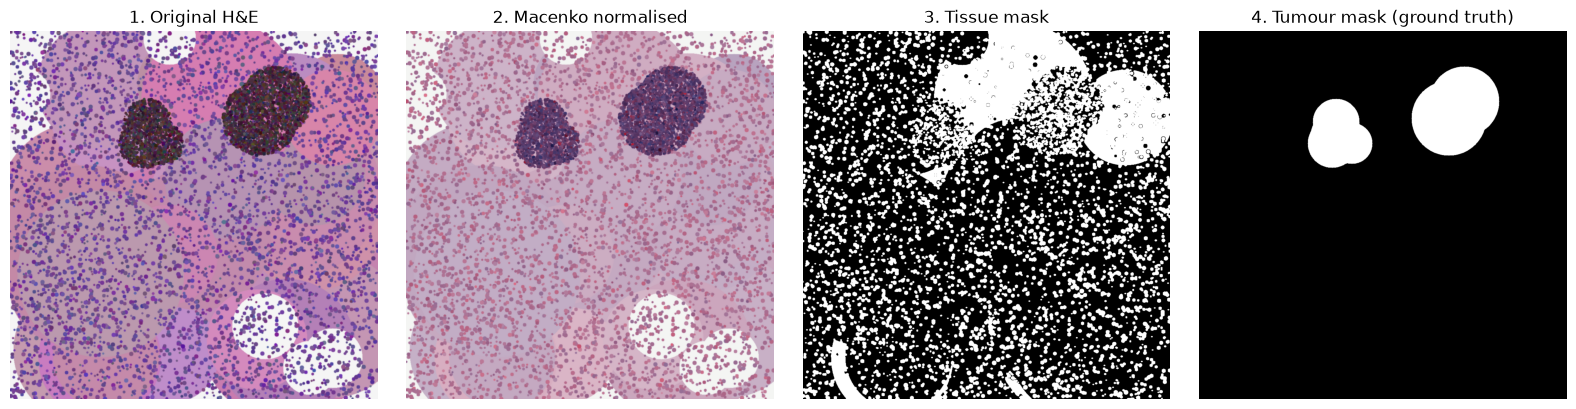

patches per magnification from this slide: {20: 3}


In [3]:
from src.utils.demo_segmentation import generate_he_slide_with_mask
from src.preprocessing.stain_normalization import MacenkoNormalizer
from src.preprocessing.tissue import tissue_mask
from src.preprocessing.patch_extraction import extract_multimag_with_mask

img, mask = generate_he_slide_with_mask(size=1024, n_tumours=2, seed=7)
norm = MacenkoNormalizer(**cfg["stain_normalization"]).normalize(img)
tm = tissue_mask(img)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(img);  ax[0].set_title("1. Original H&E");      ax[0].axis("off")
ax[1].imshow(norm); ax[1].set_title("2. Macenko normalised"); ax[1].axis("off")
ax[2].imshow(tm, cmap="gray"); ax[2].set_title("3. Tissue mask"); ax[2].axis("off")
ax[3].imshow(mask, cmap="gray"); ax[3].set_title("4. Tumour mask (ground truth)"); ax[3].axis("off")
plt.tight_layout(); plt.show()

# multi-magnification patch counts
counts = {}
for (m, y, x, p, mp) in extract_multimag_with_mask(norm, mask, [5,10,20], 20,
        256, 256, 0.5, 2000, tissue_img=img):
    counts[m] = counts.get(m, 0) + 1
print("patches per magnification from this slide:", counts)

## 4. Weeks 3–4 — U-Net segmentation (baseline vs ResNet-34)

Two U-Nets were trained: a from-scratch **baseline** and a **ResNet-34 encoder**
(transfer learning). Results below are loaded from the saved reports.

,test_dice,test_iou,params_million
unet_baseline,0.218,0.204,31.04
unet_resnet34,0.430,0.405,24.44


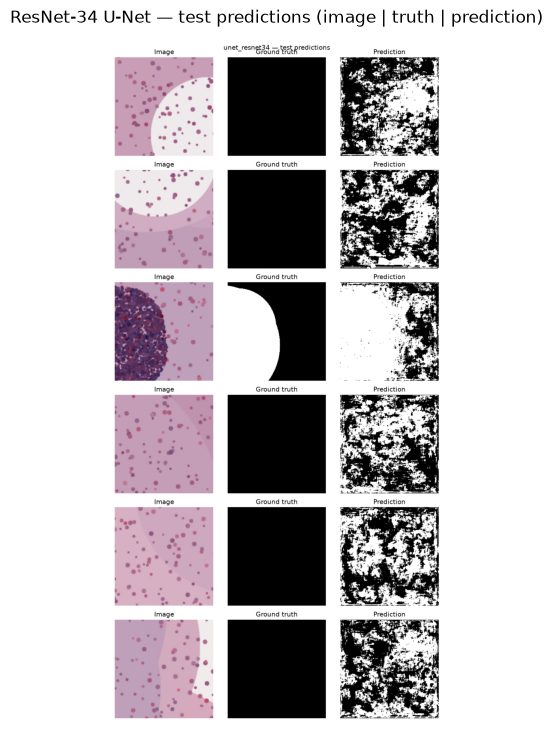

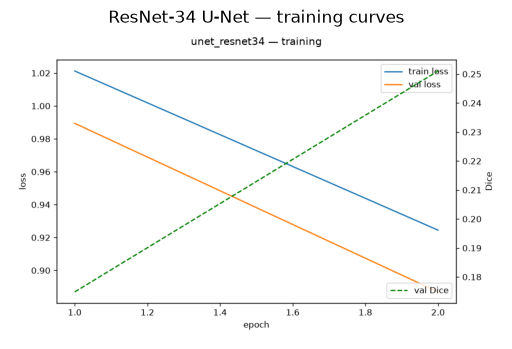

In [4]:
cmp34 = load_json("week3_4_comparison.json")
if cmp34:
    df = pd.DataFrame(cmp34).T[["test_dice","test_iou","params_million"]]
    display(df.round(3))
show_img(FIG/"unet_resnet34_predictions.png", "ResNet-34 U-Net — test predictions (image | truth | prediction)", (9,9))
show_img(FIG/"unet_resnet34_curves.png", "ResNet-34 U-Net — training curves", (7,4))

## 5. Week 5 — Attention U-Net variant (3-way comparison)

The **Attention U-Net** adds attention gates to the skip connections, focusing on
tumour regions. Built on the baseline backbone so the comparison isolates the
attention effect.

,test_dice,test_iou,test_pixel_acc,test_hausdorff,params_million,best_epoch,epochs_ran
unet_baseline,0.842,0.727,0.981,111.272,31.04,2.0,2.0
unet_resnet34,0.225,0.127,0.534,218.527,24.44,2.0,2.0
unet_attention,0.965,0.932,0.994,113.317,31.39,2.0,2.0


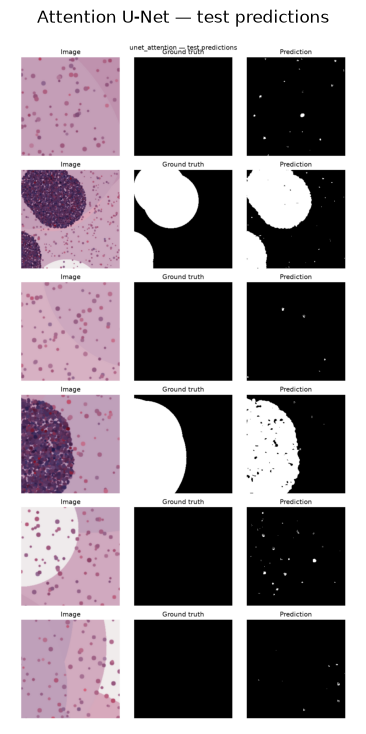

In [5]:
seg3 = load_json("week5_6_seg_comparison.json")
if seg3:
    df = pd.DataFrame(seg3).T
    display(df.round(3))
else:
    print("Run scripts/run_week5_6_pipeline.py to populate the 3-way comparison.")
show_img(FIG/"unet_attention_predictions.png", "Attention U-Net — test predictions", (9,9))

## 5b. Real-data ingestion — whole-slide reading & polygon annotations

The real CATCH slides are `.svs` whole-slide images far too large to load whole,
with tumour regions given as **polygon annotations** (MS-COCO / SQLite), not PNG
masks. Two modules make this work without any change to the downstream code:

- `src.preprocessing.wsi` — tiles a `.svs` at a chosen magnification via OpenSlide
  (tile-by-tile, never the whole slide in memory).
- `src.preprocessing.catch_annotations` — parses the COCO/SQLite polygons and
  **rasterises a binary tumour mask per tile**, aligned to the image tile.

The cell below demonstrates the annotation→mask step on a synthetic polygon (so it
runs without the multi-GB download); on real data the polygons come straight from
the CATCH COCO file.

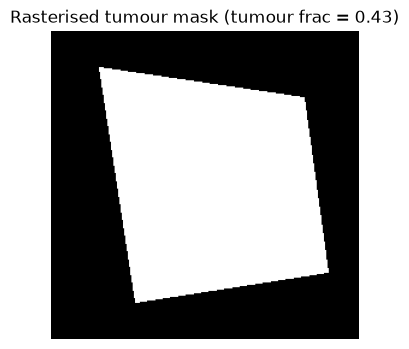

On real CATCH: open_slide(slide.svs) -> iter_tiles(...) for the image,
and load_annotations(CATCH.json) -> rasterise_tile_mask(...) for the mask.


In [6]:
import numpy as np
from src.preprocessing.catch_annotations import rasterise_tile_mask

# a synthetic tumour polygon in level-0 (whole-slide) pixel coordinates
poly = np.array([[40,30],[210,55],[230,200],[70,225]], dtype=float)
# a 256-px tile that this polygon falls inside (level-0 span = 256 px here)
mask = rasterise_tile_mask([(True, poly)], x0=0, y0=0, span0=256, patch_size=256)

plt.figure(figsize=(4,4)); plt.imshow(mask, cmap="gray")
plt.title(f"Rasterised tumour mask (tumour frac = {mask.mean():.2f})"); plt.axis("off"); plt.show()
print("On real CATCH: open_slide(slide.svs) -> iter_tiles(...) for the image,")
print("and load_annotations(CATCH.json) -> rasterise_tile_mask(...) for the mask.")

## 6. Week 6 — Tumour-subtype classification (ResNet-50)

The **classification stage** of the plan from Section 0. A **ResNet-50** (ImageNet
transfer learning, progressive unfreezing, **class-weighted** cross-entropy + label
smoothing) classifies tumour patches into subtypes. On real data this is the **7
CATCH subtypes** (or binary melanoma-vs-rest via `classification.mode`); the demo
below uses 3 colour-separable synthetic subtypes, so its perfect score reflects the
toy data, not histology. Evaluated with accuracy, macro-F1, AUC-ROC and a confusion
matrix.

Classes: ['mast_cell', 'melanocytic', 'squamous_cell']
TEST  accuracy=1.000  macro-F1=1.000  precision=1.000  recall=1.000  AUC-ROC=1.0


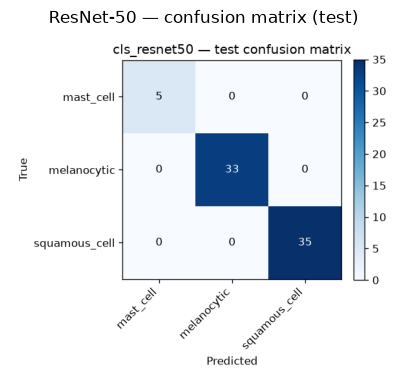

In [7]:
clsrep = load_json("cls_resnet50_test_report.json")
if clsrep:
    m = clsrep["test_metrics"]
    print("Classes:", clsrep["classes"])
    print("TEST  accuracy=%.3f  macro-F1=%.3f  precision=%.3f  recall=%.3f  AUC-ROC=%s" % (
        m["accuracy"], m["f1"], m["precision"], m["recall"],
        "n/a" if m["auc_roc"]!=m["auc_roc"] else round(m["auc_roc"],3)))
else:
    print("Run scripts/run_week5_6_pipeline.py to train + evaluate the classifier.")
show_img(FIG/"cls_resnet50_confusion.png", "ResNet-50 — confusion matrix (test)", (5,5))

## 7. How to run on the REAL CATCH dataset

Point the pipeline at the downloaded slides — the scripts auto-detect `.svs`
whole-slide images and the COCO/SQLite annotation file. **Recommended layout**
(subtype folders make labelling unambiguous):

```text
data/raw/
  Melanoma/*.svs            Mast cell tumor/*.svs   Squamous cell carcinoma/*.svs
  Peripheral nerve sheath tumor/*.svs   Trichoblastoma/*.svs
  Histiocytoma/*.svs        Plasmacytoma/*.svs
  annotations/CATCH.json    # MS-COCO polygons (tumour masks)
```

```bash
python -m src.data_acquisition.download_catch              # instructions + verify
python scripts/prepare_segmentation_data.py  --input data/raw   # WSI tiles + masks from polygons
python scripts/train_unet.py --arch attention                   # Attention U-Net
python scripts/prepare_classification_data.py --input data/raw  # tumour tiles, labelled by subtype
python scripts/train_classifier.py --arch resnet50 --epochs 20  # 7-class ResNet-50
```

> Requires the **OpenSlide** binaries on the machine (`pip install openslide-python`
> + the platform libraries from openslide.org). The download is license-gated on
> TCIA (accept the data-use agreement first). Expect a large download (~hundreds of
> GB for all 350 slides) — a few subtype folders are enough to start.

## 8. Summary & next steps (Weeks 7–8)

**Done (W1–6):** preprocessing · baseline + ResNet-34 + **Attention** U-Net
segmentation · **ResNet-50** subtype classification with class balancing · a clear
segmentation→classification plan.

**Next:** EfficientNet-B3 classifier + comparison · run on the **real CATCH**
slides · evaluation phase (5-fold cross-validation, McNemar's test, Grad-CAM).